In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import pyreadr
import joblib

import matplotlib.pyplot as plt
import plotly.express as px

from tqdm import tqdm

In [3]:
dem_uncont = pd.read_csv('transformed/dem_uncontested_seats.csv')
rep_uncont = pd.read_csv('transformed/rep_uncontested_seats.csv')

In [4]:
seat_sims = pyreadr.read_r('model_output/tot_seats_sims.RDS')[None]
seat_sims = seat_sims.rename({None: 'seats'}, axis=1)
seat_sims['seats'] = seat_sims['seats'].map(lambda x: x + dem_uncont.shape[0])
seat_sims['winner'] = seat_sims['seats'].map(lambda x: 'Democrats' if x >= 218 else 'Republicans')
seat_sims

,seats,winner
0,241,Democrats
1,215,Republicans
2,218,Democrats
3,225,Democrats
4,220,Democrats
...,...,...
19995,225,Democrats
19996,220,Democrats
19997,240,Democrats
19998,232,Democrats


In [5]:
sim_counts = seat_sims.groupby(['seats']).count().reset_index().rename({'winner': 'count'}, axis=1)
n_sims = seat_sims.shape[0]
sim_counts['pct'] = sim_counts['count'] / n_sims * 100
sim_counts['winner'] = sim_counts['seats'].map(lambda x: 'Democrats' if x >= 218 else 'Republicans')
seat_sims = pd.merge(left=seat_sims.drop(['winner'], axis=1), right=sim_counts, on='seats', how='left')
def get_desc(winner, pct, seats):
    return f'{winner} wins {seats if seats >= 218 else (435-seats)} seats in {pct:.2f}% of simulations'
#seat_sims['desc'] = seat_sims[['winner', 'pct', 'seats']].apply(lambda x: get_desc(x['winner'], x['pct'], x['seats']), axis=1)
sim_counts.head()

,seats,count,pct,winner
0,149,1,0.005,Republicans
1,154,1,0.005,Republicans
2,155,1,0.005,Republicans
3,160,2,0.010,Republicans
4,163,1,0.005,Republicans


In [6]:
np.unique(seat_sims['seats']).shape[0]

184

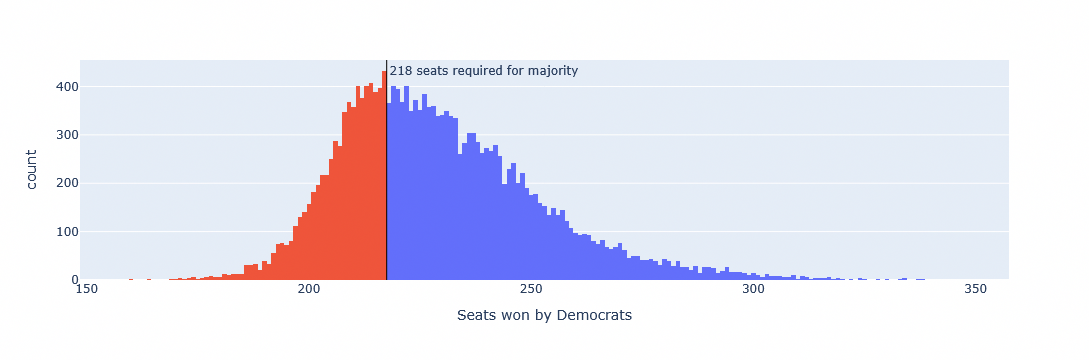

In [7]:
sims_hist = px.histogram(seat_sims, x='seats', nbins=np.unique(seat_sims['seats']).shape[0]*2, color='winner', 
                         labels={'seats':'Seats won by Democrats', 'winner': 'Winner'})
sims_hist.update_traces(showlegend=False)
sims_hist.add_vline(x=217.5, line_width=1, line_color='black', annotation_text='218 seats required for majority', 
                    annotation_position='top right')
sims_hist

In [8]:
# posterior prediction
post = pyreadr.read_r('model_output/labeled_posterior.RDS')[None]
post_untransp = post.copy()

In [9]:
post = post.T
post.head()

,0,1,2,3,4,5,6,7,8,9,...,19990,19991,19992,19993,19994,19995,19996,19997,19998,19999
AK-AL,-0.960391,-7.480199,-5.675254,-4.164947,-5.198365,-3.498182,-3.359476,0.468894,-11.639543,-1.601781,...,1.118800,-3.731849,-3.227603,-1.107235,-5.568947,-5.677180,-3.236700,-5.174406,-4.161067,-3.041260
AL-01,-10.970742,-16.718672,-16.696453,-13.639644,-14.246174,-16.624492,-17.953772,-8.906560,-18.247105,-9.310099,...,-9.703670,-10.466337,-13.440939,-12.757081,-16.586757,-16.262271,-19.804104,-11.527892,-14.980743,-11.245864
AL-02,-0.902706,-2.514048,-3.993727,-0.637077,-1.799134,-3.039908,-1.259651,-0.154459,-5.676380,-0.516839,...,2.065457,-2.375495,-2.280630,0.205989,-5.949271,2.606009,-4.010953,2.466197,0.288215,6.475775
AL-03,-15.917640,-23.407072,-23.358011,-21.812274,-21.618288,-19.807080,-22.295226,-17.057636,-25.669320,-18.701902,...,-17.565291,-20.557583,-17.682670,-22.034884,-19.649395,-20.229618,-20.646950,-20.537083,-21.594493,-21.295673
AL-04,-26.140091,-34.029788,-30.086847,-29.347812,-32.584786,-33.068979,-28.323770,-24.074411,-33.907362,-27.830492,...,-24.514601,-34.844463,-28.314919,-29.575249,-27.450459,-32.719542,-31.852794,-29.015217,-27.771366,-25.524609


In [10]:
sim_corr = post_untransp.corr()

In [11]:
sim_corr

,AK-AL,AL-01,AL-02,AL-03,AL-04,AL-05,AL-06,AL-07,AR-01,AR-02,...,WI-01,WI-03,WI-04,WI-05,WI-06,WI-07,WI-08,WV-01,WV-02,WY-AL
AK-AL,1.000000,0.719602,0.482379,0.735232,0.728448,0.721732,0.733522,0.506696,0.735050,0.740889,...,0.733741,0.553008,0.578399,0.729331,0.741779,0.704442,0.714448,0.727089,0.713617,0.700765
AL-01,0.719602,1.000000,0.491697,0.744867,0.735519,0.726570,0.739209,0.511436,0.737273,0.745562,...,0.737344,0.557339,0.583717,0.734099,0.743151,0.704351,0.723979,0.735204,0.717238,0.706611
AL-02,0.482379,0.491697,1.000000,0.505945,0.501218,0.488817,0.503304,0.698992,0.498339,0.503812,...,0.504269,0.557547,0.586836,0.500525,0.503505,0.646668,0.489984,0.502127,0.482398,0.643767
AL-03,0.735232,0.744867,0.505945,1.000000,0.761388,0.745100,0.767590,0.528335,0.757573,0.763505,...,0.757070,0.575392,0.593639,0.757831,0.764761,0.726756,0.744275,0.759854,0.735226,0.727854
AL-04,0.728448,0.735519,0.501218,0.761388,1.000000,0.736879,0.752313,0.522286,0.751134,0.755170,...,0.749228,0.562076,0.585905,0.747148,0.753324,0.718138,0.731545,0.750053,0.727197,0.719704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WI-07,0.704442,0.704351,0.646668,0.726756,0.718138,0.702476,0.720167,0.664237,0.723158,0.727312,...,0.720992,0.550324,0.567474,0.718961,0.727310,1.000000,0.704523,0.723776,0.700174,0.849210
WI-08,0.714448,0.723979,0.489984,0.744275,0.731545,0.723714,0.742002,0.508211,0.737453,0.744861,...,0.742493,0.569843,0.586241,0.740204,0.746012,0.704523,1.000000,0.740081,0.716107,0.705682
WV-01,0.727089,0.735204,0.502127,0.759854,0.750053,0.741288,0.761083,0.518265,0.756452,0.761670,...,0.754721,0.570237,0.588937,0.758912,0.761843,0.723776,0.740081,1.000000,0.740860,0.722059
WV-02,0.713617,0.717238,0.482398,0.735226,0.727197,0.718143,0.733005,0.503385,0.735461,0.741430,...,0.731989,0.555050,0.572462,0.730537,0.739961,0.700174,0.716107,0.740860,1.000000,0.697399


In [12]:
post.shape

(422, 20000)

In [13]:
def get_tipping_point(sim):
    """
    :param sim: Series representing one posterior draw or "simulation"
    :type sim: pd.Series
    """
    seats_won_dem = np.sum(sim > 0)
    if seats_won_dem >= 218 - dem_uncont.shape[0]: # Democrats win House in this draw
        sim = sim.sort_values(ascending=True)
        won_seats = sim[sim > 0]
        seat_margin = seats_won_dem - (218 - dem_uncont.shape[0])
    else: # Republicans win House in this draw
        sim = sim.sort_values(ascending=False)
        won_seats = sim[sim < 0]
        seat_margin = (435 - seats_won_dem) - (218 - rep_uncont.shape[0])
    return won_seats.iloc[seat_margin - 1], won_seats.index[seat_margin - 1]

In [14]:
tipping_points = np.array([]) # tipping point for *each sim*

for i in tqdm(range(post.shape[1])):
    sim = post.iloc[:, i]
    _, tp_seat = get_tipping_point(sim)
    tipping_points = np.append(tipping_points, tp_seat)

tipping_points

100%|███████████████████████████████████████████████████████████████████████████| 20000/20000 [00:28<00:00, 707.34it/s]


array(['MI-04', 'MI-04', 'MD-04', ..., 'OH-01', 'CO-08', 'KY-06'],
      shape=(20000,), dtype='<U32')

In [15]:
data = pd.read_csv('../../model_output/house_predictions.csv')
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",...,-6.446531,-18.764506,-1,-37.529012,44.996854,3.555843,7.905,1,37.906033,51.929138
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",...,-28.410209,-38.923019,0,-77.846039,36.050335,3.550850,0.010,2,29.083972,43.083646
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",...,-6.579341,-19.716169,1,-39.432338,47.914233,3.473542,27.050,3,41.098405,54.814359
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",...,-39.178110,-45.710827,-1,-91.421653,29.436866,3.447252,0.000,4,22.691519,36.203412
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",...,-59.470205,-47.132870,-1,-94.265741,19.710883,3.501831,0.000,5,12.855111,26.582775


In [16]:
data['tipping_point_prob'] = data['cd'].map(lambda x: np.mean(tipping_points == x) * 100)
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",...,-18.764506,-1,-37.529012,44.996854,3.555843,7.905,1,37.906033,51.929138,0.06
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",...,-38.923019,0,-77.846039,36.050335,3.550850,0.010,2,29.083972,43.083646,0.00
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",...,-19.716169,1,-39.432338,47.914233,3.473542,27.050,3,41.098405,54.814359,1.26
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",...,-45.710827,-1,-91.421653,29.436866,3.447252,0.000,4,22.691519,36.203412,0.00
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",...,-47.132870,-1,-94.265741,19.710883,3.501831,0.000,5,12.855111,26.582775,0.00


In [17]:
data.sort_values('tipping_point_prob', ascending=False).head(10)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
197,197,MI-10,Christina Hines,Mike Bouchard,False,False,MI,10,"HINES, CHRISTINA","BOUCHARD, MICHAEL",...,-3.195838,0,-6.391676,50.373146,3.611208,54.320,198,43.309037,57.436745,3.350
233,233,NC-11,Jamie Ager,Jennifer Balkcom,False,False,NC,11,"AGER, JAMIE",no_match,...,50.000000,0,100.000000,50.589775,3.612843,56.620,234,43.463690,57.707547,2.805
187,187,ME-02,Matt Dunlap,Paul LePage,False,False,ME,2,"DUNLAP, MATT","LEPAGE, PAUL",...,-4.567471,0,-9.134942,49.646020,3.613968,46.060,188,42.586858,56.799058,2.720
37,37,CA-22,Randy Villegas,David Valadao,False,True,CA,22,"VILLEGAS, RANDY","VALADAO, DAVID",...,12.732090,-1,25.464181,50.630166,3.458850,57.440,38,43.855518,57.495979,2.720
194,194,MI-07,William Lawrence,Tom Barrett,False,True,MI,7,"LAWRENCE, WILLIAM","BARRETT, THOMAS MORE",...,-25.887528,-1,-51.775056,50.527310,3.518068,56.295,195,43.575340,57.357831,2.710
318,318,PA-07,Bob Brooks,Ryan Mackenzie,False,True,PA,7,"BROOKS, BOB","MACKENZIE, RYAN EDWARD",...,6.533790,-1,13.067581,50.329360,3.513949,53.660,319,43.471169,57.205155,2.645
98,98,FL-22,Pia Dandiya,Casey Askar,False,False,FL,22,"DANDIYA, PIA","ASKAR, CASEY",...,47.144568,0,94.289136,51.418545,3.630232,65.275,99,44.238541,58.546242,2.570
191,191,MI-04,Sean McCann,Bill Huizenga,False,True,MI,4,"MCCANN, SEAN","HUIZENGA, WILLIAM P",...,7.674047,-1,15.348095,49.871435,3.444739,48.795,192,43.052488,56.595449,2.545
390,390,VA-01,Shannon Taylor,Rob Wittman,False,True,VA,1,"TAYLOR, SHANNON LEIGH","WITTMAN, ROBERT J. MR.",...,3.919277,-1,7.838555,49.692642,3.410560,46.295,391,42.973818,56.457870,2.475
277,277,NY-17,Cait Conley,Mike Lawler,False,True,NY,17,"CONLEY, CAIT","LAWLER, MICHAEL VINCENT",...,3.773526,-1,7.547052,50.559526,3.476062,56.760,278,43.640203,57.379339,2.470


In [18]:
def get_rating(dem_chance):
    if dem_chance > 100:
        raise ValueError('Invalid win chance.')
    if dem_chance > 95:
        return 'Safe D'
    elif dem_chance >= 90:
        return 'Very Likely D'
    elif dem_chance >= 75:
        return 'Likely D'
    elif dem_chance >= 65:
        return 'Lean D'
    elif dem_chance >= 60:
        return 'Tilt D'
    elif dem_chance >= 40:
        return 'Tossup'
    elif dem_chance >= 35:
        return 'Tilt R'
    elif dem_chance >= 25:
        return 'Lean R'
    elif dem_chance >= 10:
        return 'Likely R'
    elif dem_chance >= 5:
        return 'Very Likely R'
    else:
        return 'Safe R'

def get_matchup(dem_cand, rep_cand):
    indie_d = ['Bill Hill']
    indie_r = ['Kevin Kiley']
    
    if dem_cand in indie_d:
        dem_lab = dem_cand + ' (I)'
        dem_color = 'purple'
    else:
        dem_lab = dem_cand + ' (D)'
        dem_color = 'blue'
    
    if rep_cand in indie_r:
        rep_lab = rep_cand + ' (I)'
        rep_color = 'purple'
    else:
        rep_lab = rep_cand + ' (R)'
        rep_color = 'red'

    return f'<p style="color:{dem_color};">' + dem_lab + f'</p> vs <p style="color:{rep_cand}">' + rep_lab + '</p>'

In [19]:
data['rating'] = data['chance'].map(lambda x: get_rating(x))
for party in ['dem', 'rep']:
    data[f'{party}_cand'] = data[f'{party}_cand'].map(lambda x: 'TBD' if x[:3] == 'TBD' else x)
data['matchup'] = data[['dem_cand', 'rep_cand']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand']), axis=1)
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",...,-37.529012,44.996854,3.555843,7.905,1,37.906033,51.929138,0.06,Very Likely R,"<p style=""color:purple;"">Bill Hill (I)</p> vs ..."
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",...,-77.846039,36.050335,3.550850,0.010,2,29.083972,43.083646,0.00,Safe R,"<p style=""color:blue;"">Clyde Jones Jr. (D)</p>..."
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",...,-39.432338,47.914233,3.473542,27.050,3,41.098405,54.814359,1.26,Lean R,"<p style=""color:blue;"">Shomari Figures (D)</p>..."
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",...,-91.421653,29.436866,3.447252,0.000,4,22.691519,36.203412,0.00,Safe R,"<p style=""color:blue;"">Lee McInnis (D)</p> vs ..."
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",...,-94.265741,19.710883,3.501831,0.000,5,12.855111,26.582775,0.00,Safe R,"<p style=""color:blue;"">Amanda Pusczek (D)</p> ..."


In [20]:
data['projected_winner'] = data['chance'].map(lambda x: '(D)' if x > 50 else '(R)')
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",...,44.996854,3.555843,7.905,1,37.906033,51.929138,0.06,Very Likely R,"<p style=""color:purple;"">Bill Hill (I)</p> vs ...",(R)
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",...,36.050335,3.550850,0.010,2,29.083972,43.083646,0.00,Safe R,"<p style=""color:blue;"">Clyde Jones Jr. (D)</p>...",(R)
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",...,47.914233,3.473542,27.050,3,41.098405,54.814359,1.26,Lean R,"<p style=""color:blue;"">Shomari Figures (D)</p>...",(R)


In [21]:
pvi_24 = pd.read_csv('../../transformed/pvi/past_pres_results_by24dist.csv')
data = pd.merge(left=data, right=pvi_24[['district', 'party']], left_on='cd', right_on='district')
data = data.rename({'party': 'curr_party'}, axis=1)
data['hold'] = data['projected_winner'] ==  data['curr_party']
data['flip'] = data['hold'].map(lambda x: not x)
data['flip_indic'] = data['flip'].map(lambda x: 'Flip' if x else '')
#data['flip'] = data['flip'].map(lambda x: 'Yes' if x else 'No')
data.head(2)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",...,51.929138,0.06,Very Likely R,"<p style=""color:purple;"">Bill Hill (I)</p> vs ...",(R),AK-AL,(R),True,False,
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",...,43.083646,0.00,Safe R,"<p style=""color:blue;"">Clyde Jones Jr. (D)</p>...",(R),AL-01,(R),True,False,


In [22]:
data['projected_2p_margin'] = data['y_pred'].map(lambda y_pred: f'D+{y_pred - (100-y_pred):.1f}' if y_pred > 50 else f'R+{(100-y_pred) - y_pred:.1f}')
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",...,0.06,Very Likely R,"<p style=""color:purple;"">Bill Hill (I)</p> vs ...",(R),AK-AL,(R),True,False,,R+10.0
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",...,0.00,Safe R,"<p style=""color:blue;"">Clyde Jones Jr. (D)</p>...",(R),AL-01,(R),True,False,,R+27.9
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",...,1.26,Lean R,"<p style=""color:blue;"">Shomari Figures (D)</p>...",(R),AL-02,(D),False,True,Flip,R+4.2


In [23]:
data['rep_chance'] = data['chance'].map(lambda x: 100 - x)
data['rounded_dem_chance'] = data['chance'].map(lambda x: np.round(x, 1))
data['rounded_rep_chance'] = data['rep_chance'].map(lambda x: np.round(x, 1))
data['disp_dem_chance'] = data['rounded_dem_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data['disp_rep_chance'] = data['rounded_rep_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,curr_party,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",...,(R),True,False,,R+10.0,92.095,7.9,92.1,7.9%,92.1%
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",...,(R),True,False,,R+27.9,99.990,0.0,100.0,<1%,>99%
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",...,(D),False,True,Flip,R+4.2,72.950,27.0,73.0,27.0%,73.0%


In [24]:
data['swing_24_to_26'] = data['y_pred'].astype(float).map(lambda x: x - (100 - x)) - data['dem_2p_24'].astype(float).map(lambda x: x - (100 - x))
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",...,True,False,,R+10.0,92.095,7.9,92.1,7.9%,92.1%,3.686832
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",...,True,False,,R+27.9,99.990,0.0,100.0,<1%,>99%,8.445142
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",...,False,True,Flip,R+4.2,72.950,27.0,73.0,27.0%,73.0%,10.292894


In [25]:
data['geoid']

0       200
1       101
2       102
3       103
4       104
       ... 
417    5507
418    5508
419    5401
420    5402
421    5600
Name: geoid, Length: 422, dtype: int64

In [26]:
dem_uclen = dem_uncont.shape[0]
dem_uncont['rating'] = np.full(dem_uclen, 'Safe D')
dem_uncont['chance'] = np.full(dem_uclen, 100)
dem_uncont['y_pred'] = np.full(dem_uclen, 100)
dem_uncont['swing_24_to_26'] = np.full(dem_uclen, float('nan')) # Placeholder
dem_uncont['disp_dem_chance'] = np.full(dem_uclen, '100%')
dem_uncont['disp_rep_chance'] = np.full(dem_uclen, '0%')
dem_uncont['projected_2p_margin'] = np.full(dem_uclen, 'D+100')
dem_uncont['flip_indic'] = np.full(dem_uclen, '')
dem_uncont = dem_uncont.drop(['Unnamed: 0'], axis=1)
dem_uncont['matchup'] = dem_uncont[['dem_cand', 'rep_cand']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand']), axis=1)
dem_uncont.head()

,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fips,geoid,rating,chance,y_pred,swing_24_to_26,disp_dem_chance,disp_rep_chance,projected_2p_margin,flip_indic,matchup
0,CA-04,Mike Thompson/Eric Jones,Not Contested,True,False,CA,4,6,604,Safe D,100,100,NaN,100%,0%,D+100,,"<p style=""color:blue;"">Mike Thompson/Eric Jone..."
1,CA-07,Doris Matsui/Mai Vang,Not Contested,True,False,CA,7,6,607,Safe D,100,100,NaN,100%,0%,D+100,,"<p style=""color:blue;"">Doris Matsui/Mai Vang (..."
2,CA-11,Scott Weiner/Connie Chan,Not Contested,False,False,CA,11,6,611,Safe D,100,100,NaN,100%,0%,D+100,,"<p style=""color:blue;"">Scott Weiner/Connie Cha..."
3,CA-12,Lateefah Simon,Not Contested,True,False,CA,12,6,612,Safe D,100,100,NaN,100%,0%,D+100,,"<p style=""color:blue;"">Lateefah Simon (D)</p> ..."
4,CA-14,Aisha Wahab/Melissa Hernandez,Not Contested,False,False,CA,14,6,614,Safe D,100,100,NaN,100%,0%,D+100,,"<p style=""color:blue;"">Aisha Wahab/Melissa Her..."


In [27]:
rep_uclen = rep_uncont.shape[0]
rep_uncont['rating'] = np.full(rep_uclen, 'Safe R')
rep_uncont['chance'] = np.full(rep_uclen, 0)
rep_uncont['y_pred'] = np.full(rep_uclen, 0)
rep_uncont['swing_24_to_26'] = np.full(rep_uclen, float('nan')) # Placeholder
rep_uncont['disp_dem_chance'] = np.full(rep_uclen, '0%')
rep_uncont['disp_rep_chance'] = np.full(rep_uclen, '100%')
rep_uncont['projected_2p_margin'] = np.full(rep_uclen, 'R+100')
rep_uncont['flip_indic'] = np.full(rep_uclen, '')
rep_uncont = rep_uncont.drop(['Unnamed: 0'], axis=1)
rep_uncont['matchup'] = rep_uncont[['dem_cand', 'rep_cand']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand']), axis=1)
rep_uncont.head()

,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fips,geoid,rating,chance,y_pred,swing_24_to_26,disp_dem_chance,disp_rep_chance,projected_2p_margin,flip_indic,matchup
0,CA-40,Not Contested,Young Kim/Ken Calvert,False,True,CA,40,6,640,Safe R,0,0,NaN,0%,100%,R+100,,"<p style=""color:blue;"">Not Contested (D)</p> v..."


In [28]:
incl_cols = ['cd', 'dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any', 'rating', 'chance', 'disp_dem_chance',
            'disp_rep_chance', 'projected_2p_margin', 'y_pred', 'flip_indic', 'geoid', 'matchup', 'swing_24_to_26']
disp_data = pd.concat([data[incl_cols], dem_uncont[incl_cols], rep_uncont[incl_cols]], axis=0)
disp_data.shape

(435, 15)

In [29]:
tab_data = data[['cd', 'dem_cand', 'rep_cand', 'rating', 'disp_dem_chance', 'disp_rep_chance', 'projected_2p_margin', 'tipping_point_prob']]
for party in ['dem', 'rep']:
    tab_data[f'disp_{party}_chance'] = tab_data[f'disp_{party}_chance'].map(lambda x: f'<p style="color:{'blue' if party == 'dem' else 'red'};">{x}</p>')
    tab_data[f'{party}_cand'] = tab_data[f'{party}_cand'].map(lambda x: f'{x} (Ind)' if x in ['Bill Hill', 'Kevin Kiley'] else x)
tab_data = tab_data.rename({
    'cd': 'District',
    'dem_cand': 'Democrat',
    'rep_cand': 'Republican',
    'rating': 'Rating',
    'disp_dem_chance': 'Dem Chance',
    'disp_rep_chance': 'Rep Chance',
    'projected_2p_margin': 'Projected Margin',
    'tipping_point_prob': 'Tipping Point Chance'
}, axis=1)
tab_data.head()

,District,Democrat,Republican,Rating,Dem Chance,Rep Chance,Projected Margin,Tipping Point Chance
0,AK-AL,Bill Hill (Ind),Nick Begich,Very Likely R,"<p style=""color:blue;"">7.9%</p>","<p style=""color:red;"">92.1%</p>",R+10.0,0.06
1,AL-01,Clyde Jones Jr.,Jerry Carl,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+27.9,0.00
2,AL-02,Shomari Figures,Rhett Marques,Lean R,"<p style=""color:blue;"">27.0%</p>","<p style=""color:red;"">73.0%</p>",R+4.2,1.26
3,AL-03,Lee McInnis,Mike Rogers,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+41.1,0.00
4,AL-04,Amanda Pusczek,Robert Aderholt,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+60.6,0.00


In [30]:
disp_data.to_csv('display_data/choropleth_display_data.csv')
tab_data.to_csv('display_data/table_display_data.csv')